# Age Estimation - Google Colab Setup

Ce notebook configure l'environnement sur Google Colab pour le projet d'estimation d'âge.

## 1. Clone le repository GitHub

In [1]:
# Supprime le dossier s'il existe déjà (pour réexécution)
!rm -rf Deep-learning-project

# Clone le repository GitHub
!git clone https://github.com/Lduvignacq/Deep-learning-project.git
%cd Deep-learning-project

Cloning into 'Deep-learning-project'...
remote: Enumerating objects: 181, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 181 (delta 4), reused 5 (delta 4), pack-reused 171 (from 1)
Receiving objects: 100% (181/181), 34.70 MiB | 23.81 MiB/s, done.
Resolving deltas: 100% (80/80), done.
/content/Deep-learning-project


## 2. Installe les dépendances

**Note importante :** Les packages sont installés dans un ordre spécifique :
1. Packages de base et dépendances
2. PyTorch et TensorBoard
3. **albumentations** (au lieu de imgaug, compatible avec NumPy 2.0+)

✅ **Changement :** On utilise `albumentations` au lieu de `imgaug` car ce dernier n'est pas compatible avec NumPy 2.0 et Python 3.12.

In [2]:
# Mise à jour de pip et installation des dépendances
!pip install --upgrade pip -q

# Installation de better-exceptions en premier (requis par train.py)
!pip install -q better-exceptions

# Installation des packages de base
!pip install -q future pandas tqdm yacs pretrainedmodels

# Installation de PyTorch et TensorBoard
!pip install -q torch torchvision tensorboard

# Installation des packages d'images (avec albumentations au lieu de imgaug)
!pip install -q scikit-image imageio Pillow matplotlib Shapely scipy six numpy opencv-python

# Installation d'albumentations (alternative moderne à imgaug, compatible NumPy 2.0)
!pip install -q albumentations

print("✅ Installation terminée !")
print("✅ albumentations installé (compatible NumPy 2.0+)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 20.6 MB/s eta 0:00:0000:010:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
✅ Installation terminée !
✅ albumentations installé (compatible NumPy 2.0+)


✅ **Modification du code :** Le fichier `dataset.py` a été modifié pour utiliser `albumentations` au lieu de `imgaug`, ce qui résout tous les problèmes de compatibilité avec NumPy 2.0 et Python 3.12.

## 3. Télécharge le dataset APPA-REAL

In [3]:
## 3. Chargement des données depuis Google Drive

from google.colab import drive
import os

# 1. Monter le Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. Copier le fichier zip (Adapte le chemin vers ton dossier Drive)
# Imaginons que ton zip s'appelle 'UTKFace.zip'
drive_path = '/content/drive/MyDrive/appa-real-release.zip'
local_path = '/content/appa-real-release.zip'

if os.path.exists(drive_path):
    !cp "{drive_path}" "{local_path}"
    print("Fichier copié avec succès !")
    
    # 3. Extraction
    if not os.path.exists('./data'):
        !mkdir ./data
        !unzip -q {local_path} -d ./data
        print("Extraction terminée.")
else:
    print(f"Erreur : Le fichier {drive_path} n'a pas été trouvé sur ton Drive.")

Mounted at /content/drive
Fichier copié avec succès !
Extraction terminée.


## 4. Vérification du dataset

Nombre d'images chargées : 1500


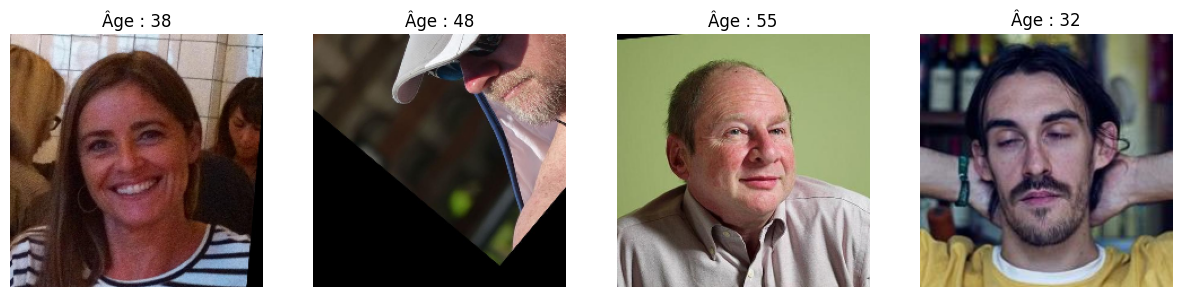

In [4]:
## 4. Vérification du Dataset
import matplotlib.pyplot as plt
import numpy as np
import torch
from dataset import FaceDataset
from torch.utils.data import DataLoader

# On instancie le dataset (on passe "." car ignore_list.csv est à la racine ici)
# Note : Si FaceDataset est dans un fichier dataset.py, l'import fonctionne.
try:
    dataset_test = FaceDataset(data_dir="./data/appa-real-release", data_type="valid", img_size=224)
    print(f"Nombre d'images chargées : {len(dataset_test)}")

    # Visualisation de quelques exemples
    loader = DataLoader(dataset_test, batch_size=4, shuffle=True)
    images, labels = next(iter(loader))

    plt.figure(figsize=(15, 5))
    for i in range(4):
        plt.subplot(1, 4, i+1)
        # On remet les dimensions dans l'ordre (C, H, W) -> (H, W, C) pour plt
        img = images[i].numpy().transpose(1, 2, 0).astype(np.uint8)
        plt.imshow(img[:,:,::-1]) # BGR (OpenCV) -> RGB (Matplotlib)
        plt.title(f"Âge : {labels[i].item()}")
        plt.axis('off')
    plt.show()
except Exception as e:
    print(f"Erreur lors du test du dataset : {e}")

## 5. Vérifie le GPU disponible

In [5]:
import torch
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Mémoire GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

CUDA disponible: False


## 6. Entraîne le modèle

⚠️ **Optimisations pour accélérer l'entraînement :**
- `TRAIN.BATCH_SIZE 64` : Batch size augmenté (32 → 64) pour plus de vitesse
- `TRAIN.WORKERS 4` : Réduit les workers (8 → 4) pour éviter la surcharge
- `TRAIN.EPOCHS 30` : Réduisez si vous voulez un test rapide (par défaut: 80)

💡 **Astuce :** Si vous obtenez "Out of Memory", remettez `TRAIN.BATCH_SIZE 32`

In [ ]:
# Essayez batch_size 64 ou 96 si le GPU le permet (plus rapide)
# Si erreur OOM, revenez à 32
!python train.py --data_dir data/appa-real-release --tensorboard tf_log TRAIN.BATCH_SIZE 64 TRAIN.WORKERS 2 TRAIN.EPOCHS 30

2026-03-10 17:52:39.278961: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773165159.299779    3995 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773165159.306559    3995 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773165159.323802    3995 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773165159.323829    3995 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773165159.323833    3995 computation_placer.cc:177] computation placer alr

## 7. Visualisations des résultats

Créez des graphiques détaillés des résultats d'entraînement

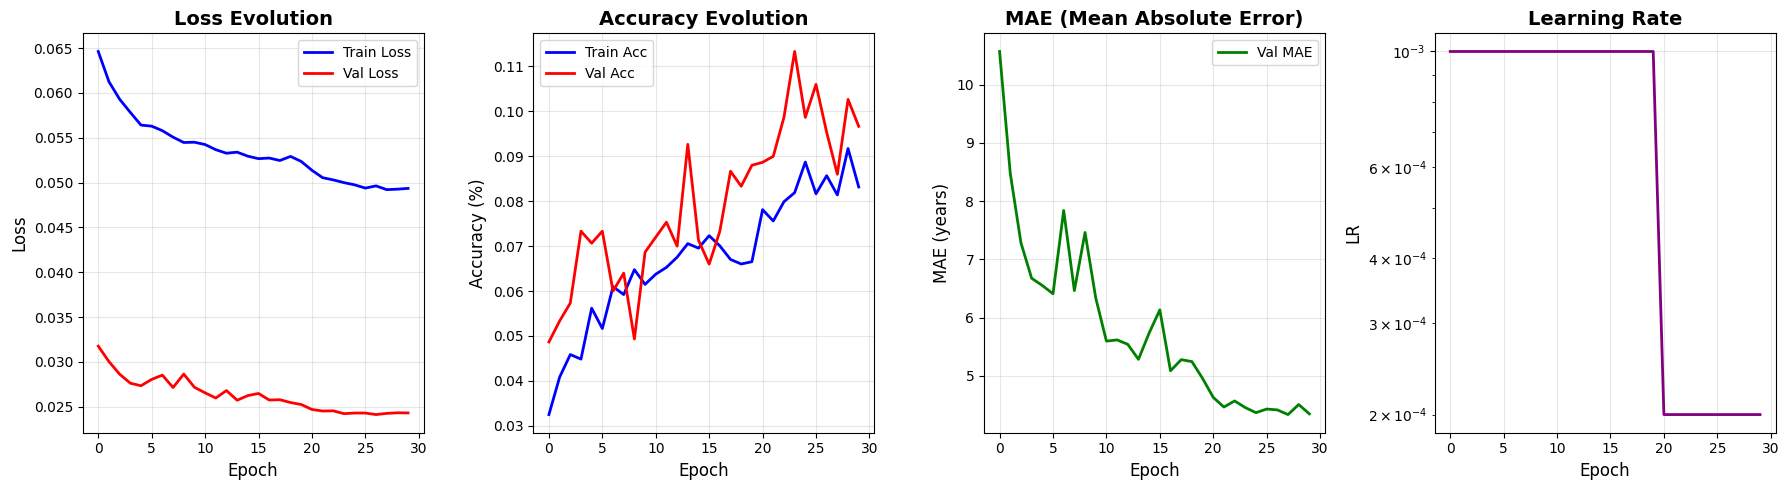

� Statistiques finales :
   Best Train Loss: 0.0492 (epoch 27)
   Best Val Loss: 0.0241 (epoch 26)
   Best Train Acc: 0.09% (epoch 28)
   Best Val Acc: 0.11% (epoch 23)
   Best MAE: 4.333 years (epoch 27)


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# Lecture des métriques sauvegardées par train.py
metrics_file = Path('checkpoint/training_metrics.csv')

if metrics_file.exists():
    df = pd.read_csv(metrics_file)
    
    plt.figure(figsize=(18, 5))
    
    # Loss
    plt.subplot(1, 4, 1)
    plt.plot(df['epoch'], df['train_loss'], 'b-', label='Train Loss', linewidth=2)
    plt.plot(df['epoch'], df['val_loss'], 'r-', label='Val Loss', linewidth=2)
    plt.title('Loss Evolution', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    
    # Accuracy
    plt.subplot(1, 4, 2)
    plt.plot(df['epoch'], df['train_acc'], 'b-', label='Train Acc', linewidth=2)
    plt.plot(df['epoch'], df['val_acc'], 'r-', label='Val Acc', linewidth=2)
    plt.title('Accuracy Evolution', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Accuracy (%)', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    
    # MAE
    plt.subplot(1, 4, 3)
    plt.plot(df['epoch'], df['val_mae'], 'g-', label='Val MAE', linewidth=2)
    plt.title('MAE (Mean Absolute Error)', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('MAE (years)', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    
    # Learning Rate
    plt.subplot(1, 4, 4)
    plt.plot(df['epoch'], df['learning_rate'], 'purple', linewidth=2)
    plt.title('Learning Rate', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('LR', fontsize=12)
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("? Statistiques finales :")
    print(f"   Best Train Loss: {df['train_loss'].min():.4f} (epoch {df.loc[df['train_loss'].idxmin(), 'epoch']:.0f})")
    print(f"   Best Val Loss: {df['val_loss'].min():.4f} (epoch {df.loc[df['val_loss'].idxmin(), 'epoch']:.0f})")
    print(f"   Best Train Acc: {df['train_acc'].max():.2f}% (epoch {df.loc[df['train_acc'].idxmax(), 'epoch']:.0f})")
    print(f"   Best Val Acc: {df['val_acc'].max():.2f}% (epoch {df.loc[df['val_acc'].idxmax(), 'epoch']:.0f})")
    print(f"   Best MAE: {df['val_mae'].min():.3f} years (epoch {df.loc[df['val_mae'].idxmin(), 'epoch']:.0f})")
else:
    print("❌ Fichier de métriques non trouvé. Entraînez d'abord le modèle (cellule 6)!")
    print(f"   Attendu : {metrics_file}")

## 8. Teste la régression

Entraîne un modèle de régression (1 sortie continue) pour comparer avec la classification (101 sorties)


In [ ]:
# Entraîne le modèle en régression (1 sortie continue)
# ⚠️ IMPORTANT: Assurez-vous que train_regression.py et model_regression.py existent
# Sinon créez-les avec les fichiers fournis

# Récupérer les branches distantes
!git fetch origin

# Basculer sur la branche (si existe localement)
!git checkout add-regression-models



# Mettre à jour avec la dernière version distante
!git pull origin add-regression-models
print("🔄 Entraînement du modèle en RÉGRESSION (1 sortie continue)...")
print("=" * 80)
!python train_regression.py --data_dir appa-real-release --tensorboard tf_log_regression TRAIN.BATCH_SIZE 96 TRAIN.WORKERS 2 TRAIN.EPOCHS 30


[Errno 2] No such file or directory: '/content/monrepo'
/content/Deep-learning-project
Already on 'add-regression-models'
Your branch is up to date with 'origin/add-regression-models'.
From https://github.com/Lduvignacq/Deep-learning-project
 * branch            add-regression-models -> FETCH_HEAD
Already up to date.
🔄 Entraînement du modèle en RÉGRESSION (1 sortie continue)...
2026-03-08 19:51:48.706974: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772999508.727568   12805 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772999508.734326   12805 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772999508.751638   12805 computation_placer

## 9. Compare Classification vs Régression

Analyse les résultats des deux approches


📊 COMPARAISON CLASSIFICATION vs RÉGRESSION

✅ CLASSIFICATION (101 classes):
   Best MAE: 4.215 years (epoch 27)
   Final Acc: 0.12%

✅ RÉGRESSION (1 sortie continue):
   Best MAE: 0.035 years (epoch 29)

✅ Régression MEILLEURE de 99.2%


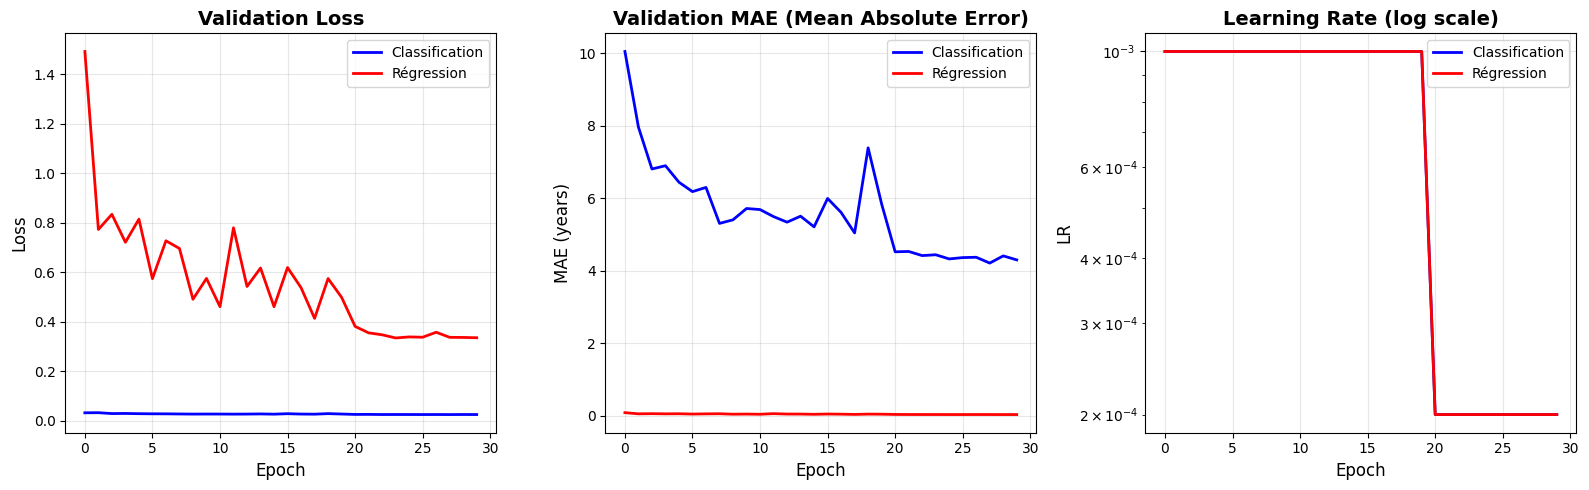

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# Chargement des métriques des deux approches
metrics_classification = Path('checkpoint/training_metrics.csv')
metrics_regression = Path('checkpoint_regression/training_metrics_regression.csv')

if metrics_classification.exists() and metrics_regression.exists():
    df_class = pd.read_csv(metrics_classification)
    df_reg = pd.read_csv(metrics_regression)
    
    print("📊 COMPARAISON CLASSIFICATION vs RÉGRESSION")
    print("=" * 80)
    print(f"\n✅ CLASSIFICATION (101 classes):")
    print(f"   Best MAE: {df_class['val_mae'].min():.3f} years (epoch {df_class.loc[df_class['val_mae'].idxmin(), 'epoch']:.0f})")
    print(f"   Final Acc: {df_class['val_acc'].iloc[-1]:.2f}%")
    
    print(f"\n✅ RÉGRESSION (1 sortie continue):")
    print(f"   Best MAE: {df_reg['val_mae'].min():.3f} years (epoch {df_reg.loc[df_reg['val_mae'].idxmin(), 'epoch']:.0f})")
    
    print("\n" + "=" * 80)
    if df_class['val_mae'].min() < df_reg['val_mae'].min():
        improvement = ((df_reg['val_mae'].min() - df_class['val_mae'].min()) / df_reg['val_mae'].min()) * 100
        print(f"✅ Classification MEILLEURE de {improvement:.1f}%")
    else:
        improvement = ((df_class['val_mae'].min() - df_reg['val_mae'].min()) / df_class['val_mae'].min()) * 100
        print(f"✅ Régression MEILLEURE de {improvement:.1f}%")
    
    # Graphiques de comparaison
    plt.figure(figsize=(16, 5))
    
    # Loss
    plt.subplot(1, 3, 1)
    plt.plot(df_class['epoch'], df_class['val_loss'], 'b-', label='Classification', linewidth=2)
    plt.plot(df_reg['epoch'], df_reg['val_loss'], 'r-', label='Régression', linewidth=2)
    plt.title('Validation Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    
    # MAE
    plt.subplot(1, 3, 2)
    plt.plot(df_class['epoch'], df_class['val_mae'], 'b-', label='Classification', linewidth=2)
    plt.plot(df_reg['epoch'], df_reg['val_mae'], 'r-', label='Régression', linewidth=2)
    plt.title('Validation MAE (Mean Absolute Error)', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('MAE (years)', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    
    # Learning Rate
    plt.subplot(1, 3, 3)
    plt.plot(df_class['epoch'], df_class['learning_rate'], 'b-', label='Classification', linewidth=2)
    plt.plot(df_reg['epoch'], df_reg['learning_rate'], 'r-', label='Régression', linewidth=2)
    plt.title('Learning Rate (log scale)', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('LR', fontsize=12)
    plt.yscale('log')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
else:
    if not metrics_classification.exists():
        print("❌ Fichier de métriques classification non trouvé")
        print(f"   Attendu : {metrics_classification}")
    if not metrics_regression.exists():
        print("❌ Fichier de métriques régression non trouvé")
        print(f"   Attendu : {metrics_regression}")
        print("   Exécutez d'abord la cellule précédente pour entraîner le modèle de régression")


## 10. Analyse de performance par tranche d'âge

Évalue la précision du modèle selon différentes tranches d'âge

Device: cuda
Loading regression checkpoint: epoch029_0.33463_4.4083.pth


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


MAE regression (test vs dataset labels): 5.2461


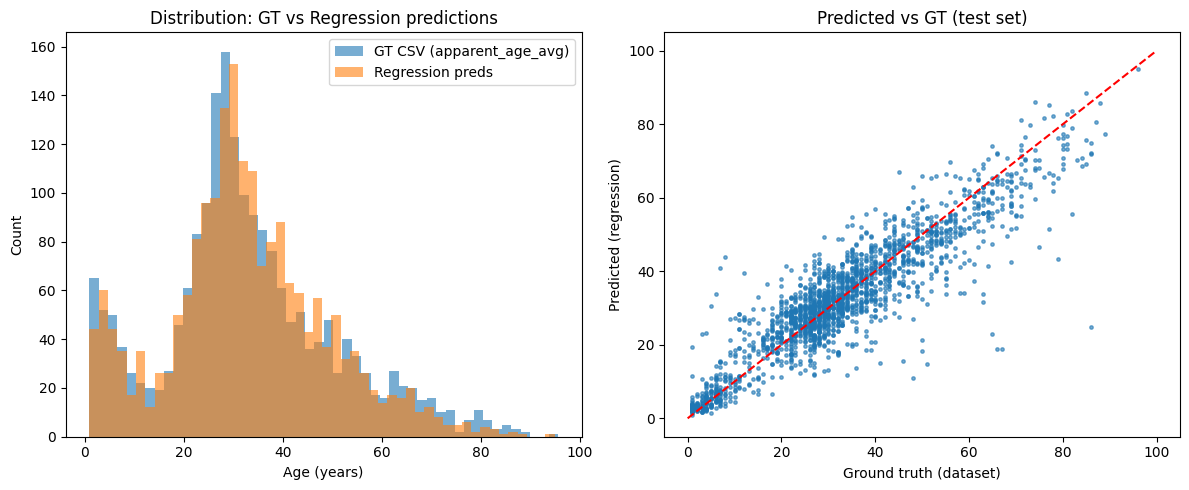

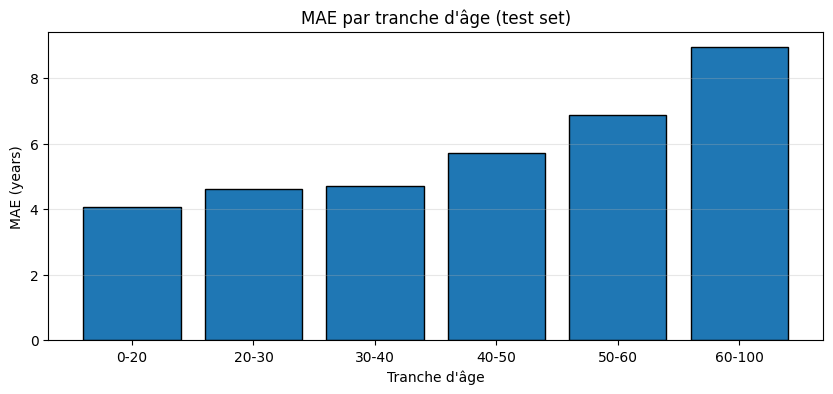

Échantillon résultats (10 premiers):
0: gt=23.0, pred=22.99, err=0.01
1: gt=71.0, pred=57.69, err=13.31
2: gt=55.0, pred=44.40, err=10.60
3: gt=24.0, pred=27.22, err=3.22
4: gt=25.0, pred=29.96, err=4.96
5: gt=35.0, pred=52.51, err=17.51
6: gt=27.0, pred=21.21, err=5.79
7: gt=48.0, pred=46.86, err=1.14
8: gt=19.0, pred=17.74, err=1.26
9: gt=57.0, pred=58.91, err=1.91


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch
from pathlib import Path
from dataset import FaceDataset
from model_regression import get_model_regression
from defaults import _C as cfg
from torch.utils.data import DataLoader

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

csv_path = Path('appa-real-release/gt_avg_test.csv')
ckpt_dir = Path('checkpoint_regression')

if not csv_path.exists():
    print('❌ Fichier CSV du dataset test non trouvé:', csv_path)
else:
    if not ckpt_dir.exists():
        print('❌ Dossier checkpoint_regression/ non trouvé. Placez vos .pth dedans.')
    else:
        ckpts = list(ckpt_dir.glob('*.pth'))
        if not ckpts:
            print('❌ Aucun .pth trouvé dans checkpoint_regression/')
        else:
            def score(p):
                try:
                    return float(p.stem.split('_')[-1])
                except Exception:
                    return float('inf')
            best = min(ckpts, key=score)
            print(f'Loading regression checkpoint: {best.name}')
            model = get_model_regression(model_name=cfg.MODEL.ARCH, pretrained=None).to(device)
            ck = torch.load(str(best), map_location='cpu')
            model.load_state_dict(ck['state_dict'])
            model.eval()

            # Eval on test set to get preds and gts
            test_ds = FaceDataset('appa-real-release', 'test', img_size=cfg.MODEL.IMG_SIZE, augment=False)
            test_loader = DataLoader(test_ds, batch_size=cfg.TEST.BATCH_SIZE, shuffle=False, num_workers=4, drop_last=False)
            preds = []
            gts = []
            with torch.no_grad():
                for x, y in test_loader:
                    x = x.to(device)
                    out = model(x)
                    pred = out.squeeze(1).cpu().numpy()
                    preds.append(pred)
                    gts.append(y.numpy())
            preds = np.concatenate(preds)
            gts = np.concatenate(gts)
            mae = np.abs(preds - gts).mean()
            print(f'MAE regression (test vs dataset labels): {mae:.4f}')

            # Read CSV for distribution (apparent_age_avg)
            df = pd.read_csv(csv_path)
            # Use gts (from dataset) which may be rounded ints; convert to float for plotting
            plt.figure(figsize=(12,5))
            plt.subplot(1,2,1)
            plt.hist(df['apparent_age_avg'], bins=50, alpha=0.6, label='GT CSV (apparent_age_avg)', density=False)
            plt.hist(preds, bins=50, alpha=0.6, label='Regression preds', density=False)
            plt.legend()
            plt.title('Distribution: GT vs Regression predictions')
            plt.xlabel('Age (years)')
            plt.ylabel('Count')

            plt.subplot(1,2,2)
            plt.scatter(gts, preds, s=6, alpha=0.6)
            plt.plot([0, 100], [0, 100], 'r--')
            plt.xlabel('Ground truth (dataset)')
            plt.ylabel('Predicted (regression)')
            plt.title('Predicted vs GT (test set)')
            plt.tight_layout()
            plt.show()

            # MAE per age-bin
            age_bins = [(0,20),(20,30),(30,40),(40,50),(50,60),(60,100)]
            bins_labels = [f'{a}-{b}' for a,b in age_bins]
            maes = []
            counts = []
            for a,b in age_bins:
                idx = np.where((gts >= a) & (gts < b))[0]
                counts.append(len(idx))
                if len(idx):
                    maes.append(np.abs(preds[idx] - gts[idx]).mean())
                else:
                    maes.append(np.nan)
            plt.figure(figsize=(10,4))
            plt.bar(bins_labels, maes, edgecolor='black')
            plt.title('MAE par tranche d\'âge (test set)')
            plt.xlabel('Tranche d\'âge')
            plt.ylabel('MAE (years)')
            plt.grid(True, axis='y', alpha=0.3)
            plt.show()

            print('Échantillon résultats (10 premiers):')
            for i in range(min(10, len(preds))):
                print(f'{i}: gt={gts[i]:.1f}, pred={preds[i]:.2f}, err={abs(preds[i]-gts[i]):.2f}')


## 11. Aleatoric Laplacian 

In [ ]:
# --- 1. SÉCURITÉ & BRANCH ---
import os


# On s'assure d'être sur la bonne branche et d'avoir les fichiers
!git checkout aleatoric 2>/dev/null || !git checkout -b aleatoric
!git pull origin aleatoric 2>/dev/null

# --- 2. ENTRAÎNEMENT ---
# On lance l'entraînement avec la distribution Laplace (plus robuste)
# Ajuste les paramètres selon tes besoins
dist_type = "laplace" 
checkpoint_path = "checkpoint_aleatoric"

print(f"\n>>> Lancement de l'entraînement Aleatoric ({dist_type})...\n")
!python train_aleatoric.py --data_dir ./data/appa-real-release/ --checkpoint checkpoint_ale --dist laplace --epochs 20



Your branch is up to date with 'origin/aleatoric'.
Already up to date.

>>> Lancement de l'entraînement Aleatoric (laplace)...

2026-03-10 18:47:07.415227: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773168427.436043   18002 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773168427.442938   18002 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773168427.461113   18002 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773168427.461137   18002 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid

## 12.Evaluation

Chargement du meilleur modèle : checkpoint_ale/best.pth


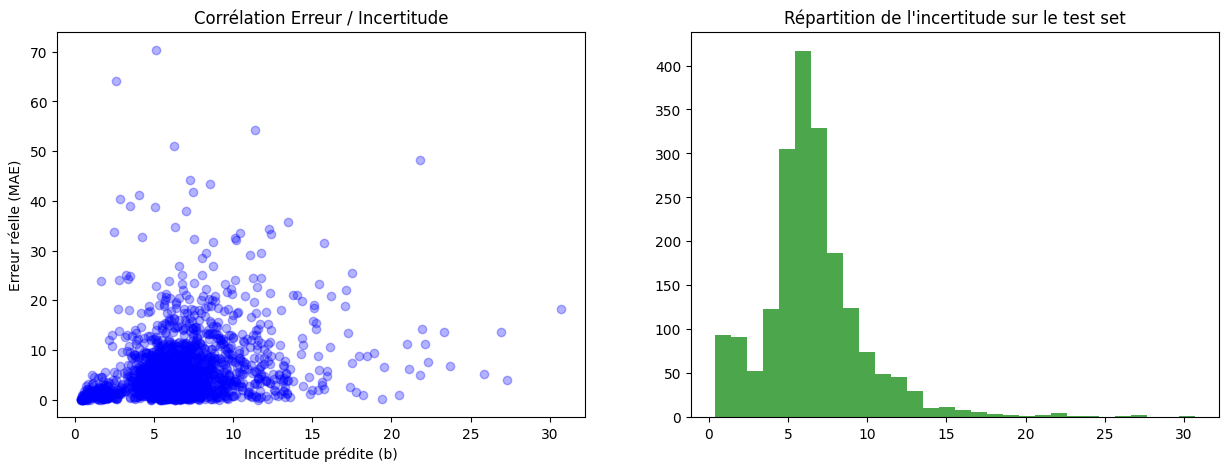


--- RÉSULTATS FINAUX ---
MAE Global : 5.76 ans
MAE sur les 10% d'images les plus sûres : 1.96 ans


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from model_aleatoric import get_model_aleatoric
from dataset import FaceDataset
from torch.utils.data import DataLoader

data_dir = "./data/appa-real-release/"
checkpoint_ale = "checkpoint_ale"
checkpoint_reg = "checkpoint_regression" # Ton dossier de train standard
dist_type = "laplace"

def evaluate_robust(path_ale, path_reg):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Vérification des fichiers .pth
    checkpoints = sorted(list(Path(path_ale).glob("*.pth")))
    if not checkpoints:
        print(f"ERREUR : Aucun fichier .pth trouvé dans {path_ale}. Vérifie si l'entraînement a bien sauvegardé un modèle.")
        return
    
    best_pth = checkpoints[-1]
    print(f"Chargement du meilleur modèle : {best_pth}")

    # Chargement du modèle
    model = get_model_aleatoric().to(device)
    checkpoint_data = torch.load(best_pth, map_location=device)
    
    # Gestion de la structure du dictionnaire (state_dict ou direct)
    if 'state_dict' in checkpoint_data:
        model.load_state_dict(checkpoint_data['state_dict'])
    else:
        model.load_state_dict(checkpoint_data)
    model.eval()

    # Inférence sur le set de test
    ds = FaceDataset(data_dir, data_type="test", img_size=224)
    loader = DataLoader(ds, batch_size=32, shuffle=False)

    all_preds, all_gts, all_uncert = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            out = model(imgs)
            all_preds.extend(out[:, 0].cpu().numpy())
            # Incertitude : b (Laplace) ou sigma (Gauss)
            all_uncert.extend(torch.exp(out[:, 1]).cpu().numpy())
            all_gts.extend(labels.numpy())

    preds, gts, uncert = np.array(all_preds), np.array(all_gts), np.array(all_uncert)
    errors = np.abs(preds - gts)

    # --- AFFICHAGE DES RÉSULTATS ---
    plt.figure(figsize=(15, 5))
    
    # 1. Validation de l'incertitude
    plt.subplot(1, 2, 1)
    plt.scatter(uncert, errors, alpha=0.3, color='blue')
    plt.xlabel("Incertitude prédite (b)")
    plt.ylabel("Erreur réelle (MAE)")
    plt.title("Corrélation Erreur / Incertitude")
    
    # 2. Histogramme de l'incertitude
    plt.subplot(1, 2, 2)
    plt.hist(uncert, bins=30, color='green', alpha=0.7)
    plt.title("Répartition de l'incertitude sur le test set")
    plt.show()

    print(f"\n--- RÉSULTATS FINAUX ---")
    print(f"MAE Global : {errors.mean():.2f} ans")
    
    # Comparaison avec les 10% les plus sûrs
    idx_sure = np.argsort(uncert)[:len(uncert)//10]
    print(f"MAE sur les 10% d'images les plus sûres : {errors[idx_sure].mean():.2f} ans")

# Lancement
evaluate_robust(checkpoint_ale, checkpoint_reg)

Note: metrics.csv non trouvé dans checkpoint_ale. Utilise Tensorboard pour les courbes.


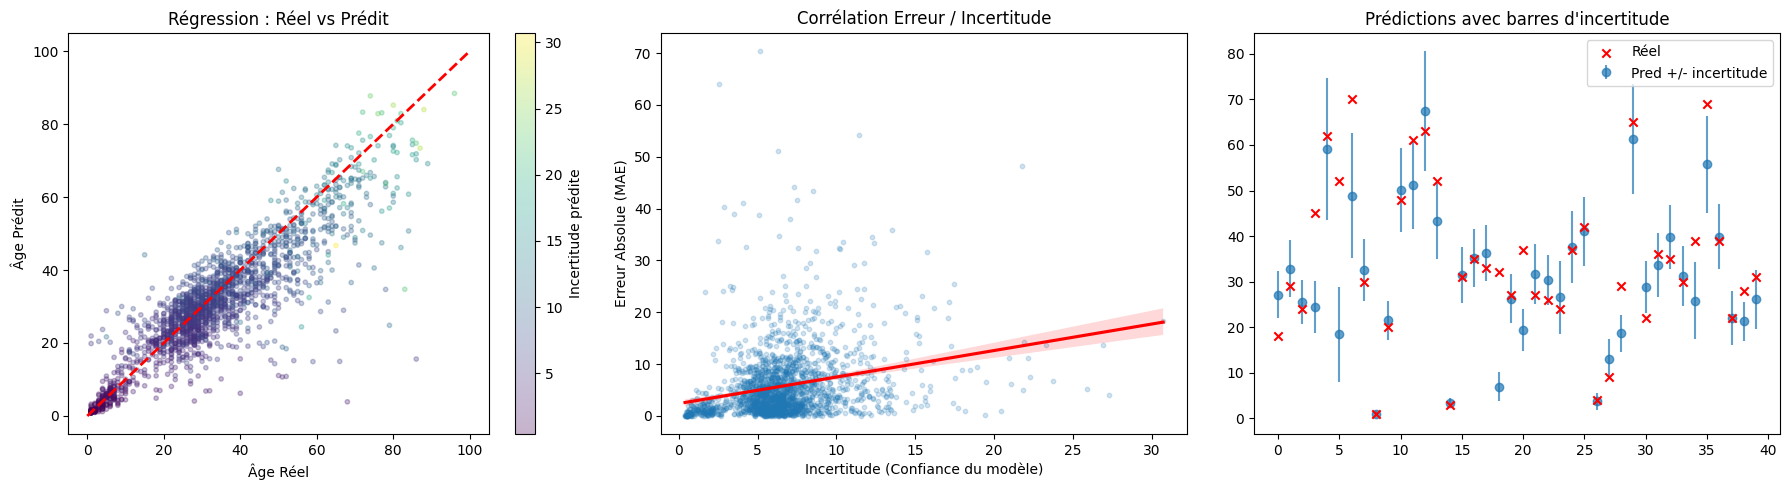

MAE sur les 10% d'images les plus 'sûres' (incertitude < 2.64): 1.97 ans
MAE moyen sur tout le test set: 5.76 ans


In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from torch.utils.data import DataLoader
from model_aleatoric import get_model_aleatoric
from dataset import FaceDataset

# --- CONFIGURATION ---
data_dir = "./data/appa-real-release/"
checkpoint_ale = "checkpoint_ale"
dist_type = "laplace" # "laplace" ou "gaussian"

def plot_training_results(checkpoint_path):
    # 1. Chargement des métriques (si ton script sauve un CSV comme train_regression.py)
    csv_path = Path(checkpoint_path) / "metrics.csv"
    
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        
        plt.figure(figsize=(12, 5))
        
        # Courbe de Loss
        plt.subplot(1, 2, 1)
        plt.plot(df['epoch'], df['train_loss'], label='Train Loss')
        plt.plot(df['epoch'], df['val_loss'], label='Val Loss')
        plt.title('Évolution de la Loss Aleatoric')
        plt.xlabel('Époque')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Courbe de MAE
        plt.subplot(1, 2, 2)
        plt.plot(df['epoch'], df['train_mae'], label='Train MAE')
        plt.plot(df['epoch'], df['val_mae'], label='Val MAE')
        plt.title('Évolution du MAE (Années)')
        plt.xlabel('Époque')
        plt.ylabel('MAE')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
    else:
        print(f"Note: metrics.csv non trouvé dans {checkpoint_path}. Utilise Tensorboard pour les courbes.")

def deep_analysis(path_ale):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Charger le meilleur modèle
    checkpoints = sorted(list(Path(path_ale).glob("*.pth")))
    if not checkpoints: return
    model = get_model_aleatoric().to(device)
    ckpt = torch.load(checkpoints[-1], map_location=device)
    model.load_state_dict(ckpt['state_dict'] if 'state_dict' in ckpt else ckpt)
    model.eval()

    # Inférence sur Test
    ds = FaceDataset(data_dir, data_type="test")
    loader = DataLoader(ds, batch_size=32, shuffle=False)
    
    preds, gts, uncerts = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            out = model(imgs)
            preds.extend(out[:, 0].cpu().numpy())
            # On convertit log_var en échelle réelle (b pour Laplace, sigma pour Gauss)
            u = torch.exp(out[:, 1]) if dist_type == "laplace" else torch.exp(0.5 * out[:, 1])
            uncerts.extend(u.cpu().numpy())
            gts.extend(labels.numpy())
    
    preds, gts, uncerts = np.array(preds), np.array(gts), np.array(uncerts)
    errors = np.abs(preds - gts)

    # --- GRAPHIQUES ---
    plt.figure(figsize=(18, 5))

    # 1. Âge Réel vs Âge Prédit
    plt.subplot(1, 3, 1)
    plt.scatter(gts, preds, alpha=0.3, s=10, c=uncerts, cmap='viridis')
    plt.plot([0, 100], [0, 100], 'r--', lw=2)
    plt.colorbar(label='Incertitude prédite')
    plt.xlabel('Âge Réel')
    plt.ylabel('Âge Prédit')
    plt.title('Régression : Réel vs Prédit')
    
    # 2. Distribution de l'Erreur par rapport à l'Incertitude (Jointplot style)
    plt.subplot(1, 3, 2)
    sns.regplot(x=uncerts, y=errors, scatter_kws={'alpha':0.2, 's':10}, line_kws={'color':'red'})
    plt.xlabel('Incertitude (Confiance du modèle)')
    plt.ylabel('Erreur Absolue (MAE)')
    plt.title('Corrélation Erreur / Incertitude')

    # 3. Graphique d'Intervalle (Top 50 échantillons)
    plt.subplot(1, 3, 3)
    sample_idx = np.random.choice(len(preds), 40)
    x = np.arange(40)
    plt.errorbar(x, preds[sample_idx], yerr=uncerts[sample_idx], fmt='o', label='Pred +/- incertitude', alpha=0.7)
    plt.scatter(x, gts[sample_idx], color='red', marker='x', label='Réel', zorder=3)
    plt.title('Prédictions avec barres d\'incertitude')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

    # Affichage des statistiques de "calibration"
    q10 = np.percentile(uncerts, 10)
    print(f"MAE sur les 10% d'images les plus 'sûres' (incertitude < {q10:.2f}): {errors[uncerts <= q10].mean():.2f} ans")
    print(f"MAE moyen sur tout le test set: {errors.mean():.2f} ans")

# Exécution
plot_training_results(checkpoint_ale)
deep_analysis(checkpoint_ale)